In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

* Loading dataset

In [28]:
df=pd.read_csv('real_estate_missing_all_columns_except_id.csv')
df.head(10)

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973.0,5.0,4.0,7.6,23.0,11.9,5220.0,1.0,0.0,0.0,40275084.0
1,100002,1560.0,3.0,3.0,6.3,13.0,15.8,3882.0,1.0,0.0,13.0,26812029.0
2,100003,2071.0,4.0,3.0,5.8,9.0,21.1,NaN,0.0,0.0,9.0,29315677.0
3,100004,2640.0,5.0,3.0,NaN,12.0,7.9,NaN,1.0,1.0,4.0,47712959.0
4,100005,1498.0,3.0,3.0,3.8,15.0,24.0,2663.0,0.0,NaN,15.0,17724566.0
5,100006,1498.0,3.0,NaN,7.4,9.0,13.3,2050.0,0.0,0.0,9.0,26448337.0
6,100007,2676.0,6.0,6.0,NaN,16.0,14.5,7215.0,1.0,0.0,16.0,44768109.0
7,100008,2149.0,2.0,1.0,5.9,19.0,17.4,2268.0,1.0,0.0,9.0,30291804.0
8,100009,NaN,NaN,1.0,4.7,37.0,12.5,3977.0,0.0,NaN,32.0,16161989.0
9,100010,2003.0,4.0,3.0,1.0,31.0,18.4,5554.0,1.0,NaN,17.0,12273622.0


* Identify null value

In [29]:
df.isnull().sum()

house_id                  0
area_sqft               252
bedrooms                252
bathrooms               252
location_score          252
age_years               252
distance_city_km        252
lot_size_sqft           252
has_garage              252
has_pool                252
renovation_years_ago    252
house_price_inr         252
dtype: int64

* Pandas profiling

In [ ]:
from ydata_profiling import ProfileReport
report=ProfileReport(df)
report.to_file('real_estate_missing_all_columns_except_id.html')

* Univariate analysis and filling missing values using mean imputer.

C:\Users\adity\AppData\Local\Temp\ipykernel_12908\987642040.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area_sqft'])


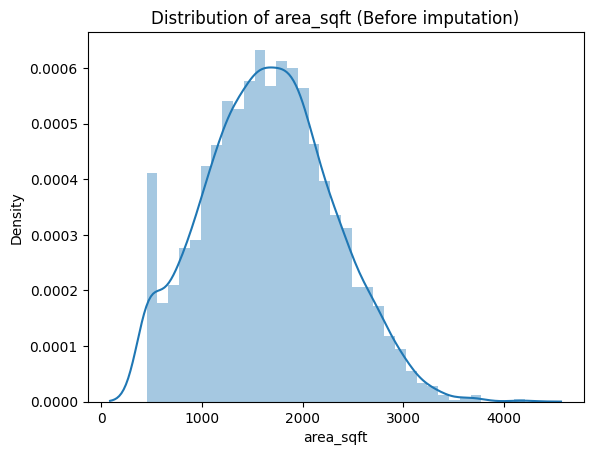

C:\Users\adity\AppData\Local\Temp\ipykernel_12908\987642040.py:14: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['area_sqft'])


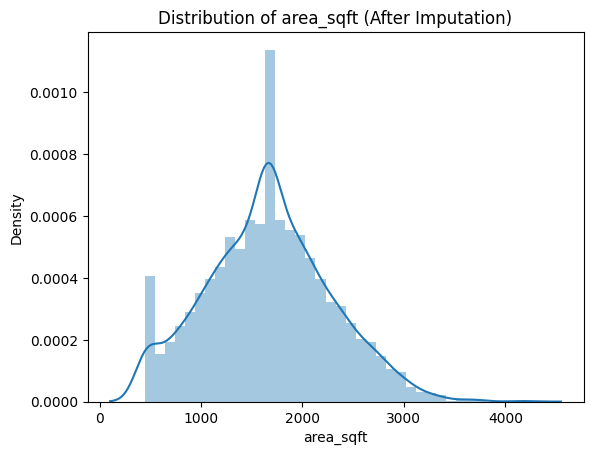

In [31]:
from sklearn.impute import SimpleImputer

plt.figure()
sns.distplot(df['area_sqft'])
plt.title("Distribution of area_sqft (Before imputation)")
plt.xlabel("area_sqft")
plt.ylabel("Density")
plt.show()

imputer=SimpleImputer(strategy='mean')
df['area_sqft']=imputer.fit_transform(df[['area_sqft']])

plt.figure()
sns.distplot(df['area_sqft'])
plt.title("Distribution of area_sqft (After Imputation)")
plt.xlabel("area_sqft")
plt.ylabel("Density")
plt.show()

* Bivariate analysis and filling missing values using median imptation.

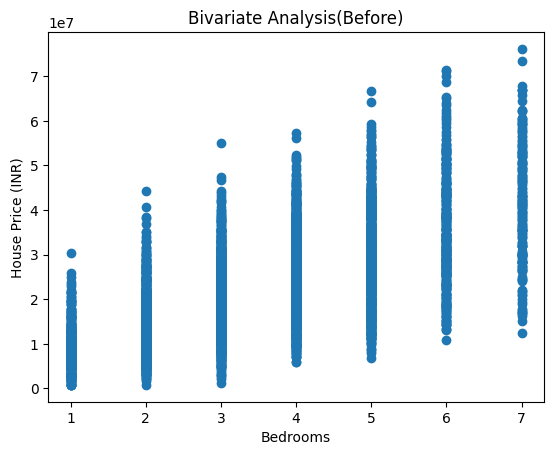

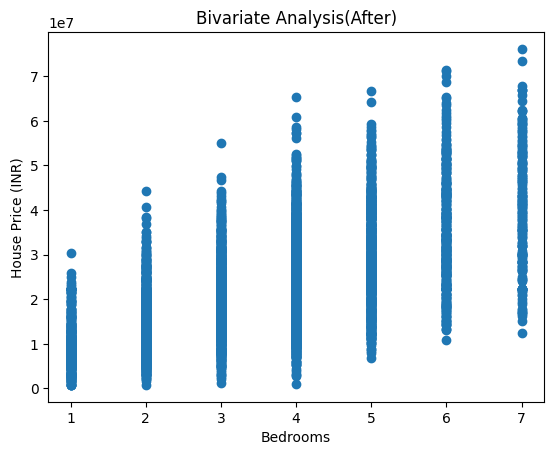

In [32]:
plt.figure()
plt.scatter(df['bedrooms'], df['house_price_inr'])
plt.xlabel("Bedrooms")
plt.ylabel("House Price (INR)")
plt.title("Bivariate Analysis(Before)")
plt.show()

imputer2=SimpleImputer(strategy='median')
df['bedrooms'] = imputer2.fit_transform(df[['bedrooms']])
df['house_price_inr'] = imputer2.fit_transform(df[['house_price_inr']])

plt.figure()
plt.scatter(df['bedrooms'], df['house_price_inr'])
plt.xlabel("Bedrooms")
plt.ylabel("House Price (INR)")
plt.title("Bivariate Analysis(After)")
plt.show()

* Filling missing values in remaining numerical columns

In [33]:
# bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,renovation_years_ago

num_col_mean=df[['location_score','age_years','distance_city_km','lot_size_sqft']]
for i in num_col_mean.columns:
    df[i]=imputer.fit_transform(df[[i]])

num_col_meadian=df[['bathrooms','renovation_years_ago']]
for j in num_col_meadian.columns:
    df[j]=imputer2.fit_transform(df[[j]])

df.isnull().sum()

house_id                  0
area_sqft                 0
bedrooms                  0
bathrooms                 0
location_score            0
age_years                 0
distance_city_km          0
lot_size_sqft             0
has_garage              252
has_pool                252
renovation_years_ago      0
house_price_inr           0
dtype: int64

* Filling missing values in remaining categorical columns (mode imputer)

In [34]:
# from sklearn.impute import KNNImputer
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer

imputer_mode = SimpleImputer(strategy='most_frequent')
df['has_garage'] = imputer_mode.fit_transform(df[['has_garage']])
df['has_pool'] = imputer_mode.fit_transform(df[['has_pool']])

print(df.isnull().sum())
imputer_mode

house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64


SimpleImputer(strategy='most_frequent')

* Handling Outliers

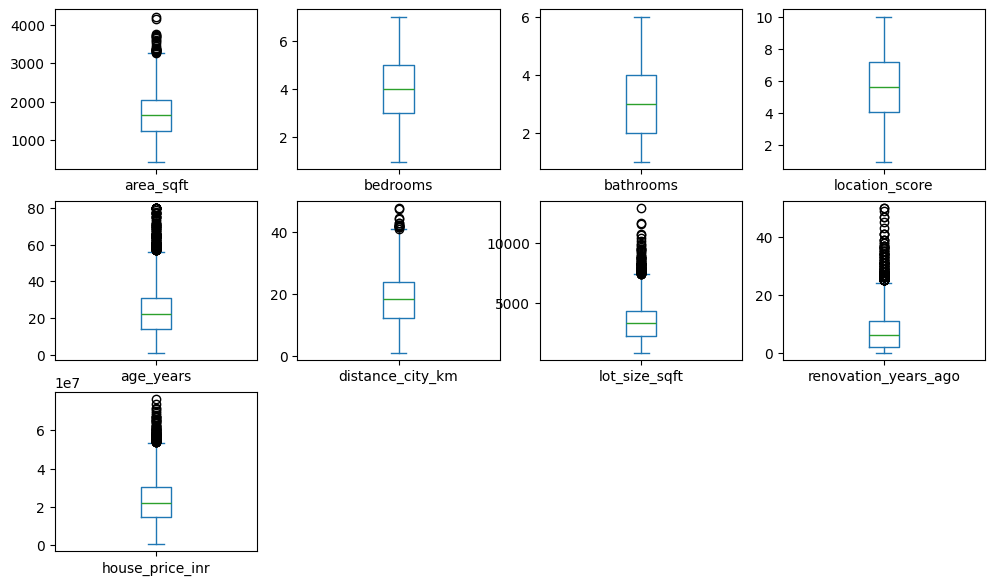

In [35]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop(['house_id','has_pool','has_garage'], errors='ignore')

df[num_cols].plot(kind='box', subplots=True, layout=(5,4), figsize=(12,12))
# plt.tight_layout()
plt.show()

* Detect and remove outliers using z-score

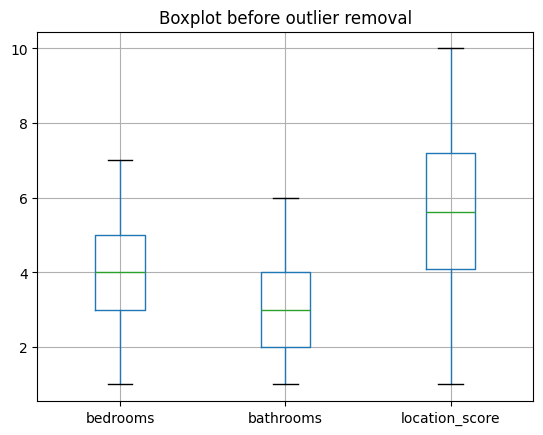

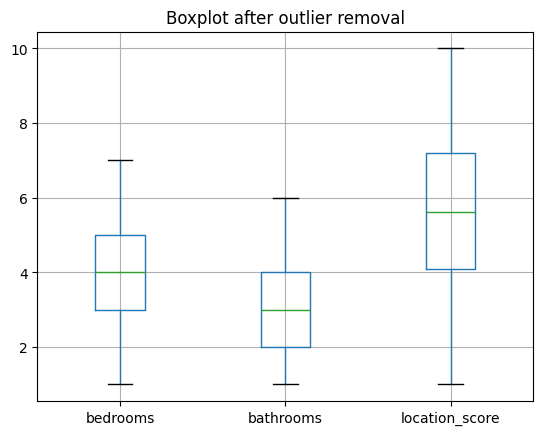

In [36]:
from scipy import stats

df[['bedrooms','bathrooms','location_score']].boxplot()
plt.title("Boxplot before outlier removal")
plt.show()

cols = ['bedrooms','bathrooms','location_score']
z_scores = np.abs(stats.zscore(df[cols]))
outliers = (z_scores > 3)
df = df[(z_scores < 3).all(axis=1)]
outlier_zscores = z_scores[(z_scores > 3).any(axis=1)]

df[['bedrooms','bathrooms','location_score']].boxplot()
plt.title("Boxplot after outlier removal")
plt.show()

* Removing outliers using IQR

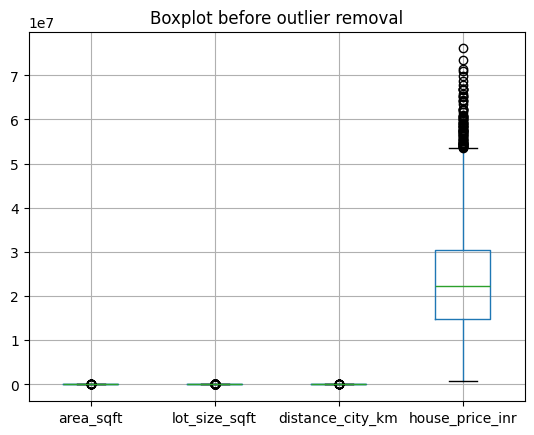

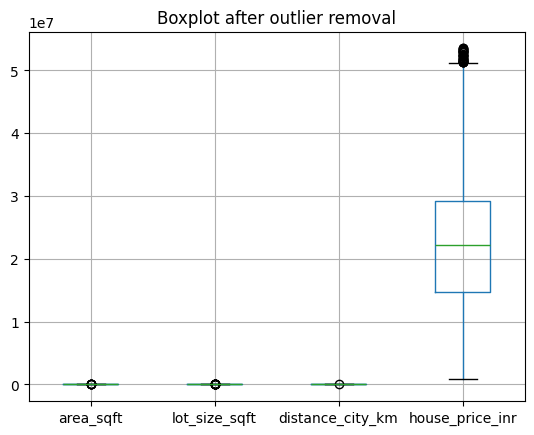

In [37]:
cols_2 = ['area_sqft','lot_size_sqft','distance_city_km','house_price_inr']
df[cols_2].boxplot()
plt.title("Boxplot before outlier removal")
plt.show()

Q1 = df[cols_2].quantile(0.25)
Q3 = df[cols_2].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers_2 = ((df[cols_2] < lower_bound) | (df[cols_2] > upper_bound))
outlier_values = df[cols_2][outliers_2.any(axis=1)]

df = df[~((df[cols_2] < lower_bound) | (df[cols_2] > upper_bound)).any(axis=1)]

df[cols_2].boxplot()
plt.title("Boxplot after outlier removal")
plt.show()

* Removing outliers using Winsorization

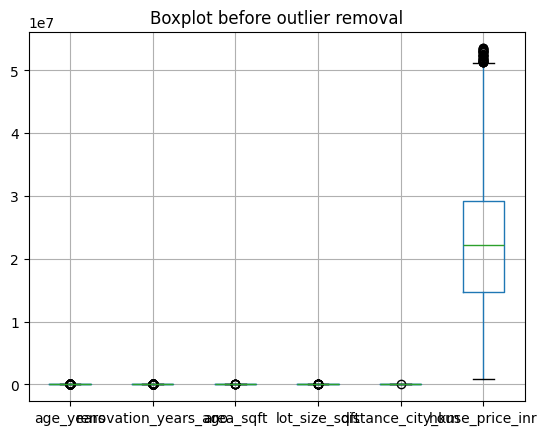

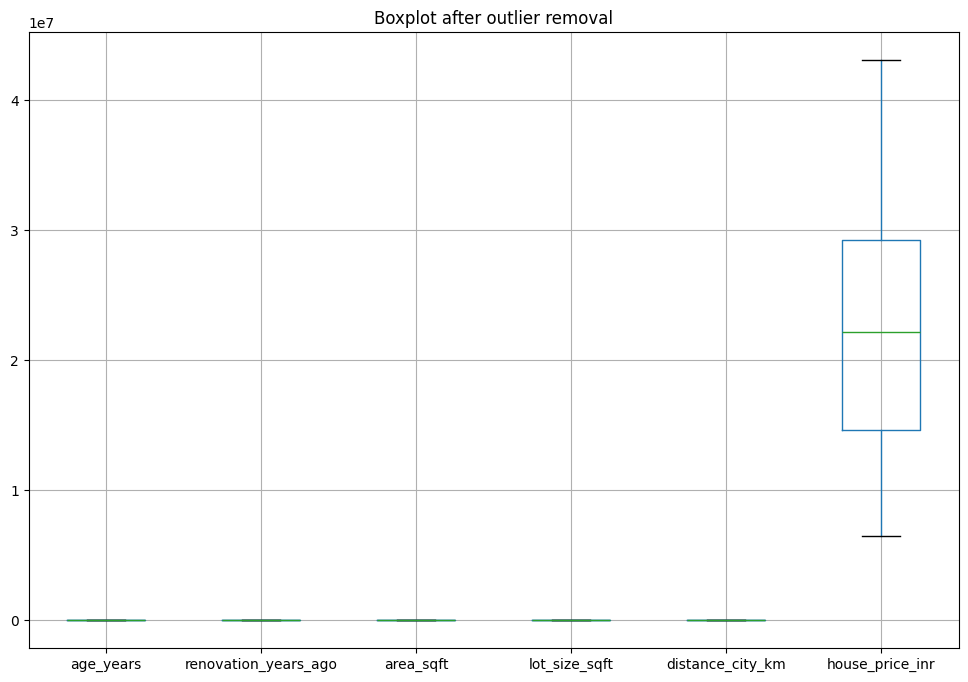

In [38]:
from scipy.stats.mstats import winsorize

cols_3 = ['age_years','renovation_years_ago','area_sqft','lot_size_sqft','distance_city_km','house_price_inr']
df[cols_3].boxplot()
plt.title("Boxplot before outlier removal")
plt.show()

for col_4 in cols_3:
    df[col_4] = winsorize(df[col_4], limits=[0.05,0.05])

fig=df[cols_3].boxplot(figsize=(12,8))
plt.title("Boxplot after outlier removal")
plt.show()

* After removing outliers

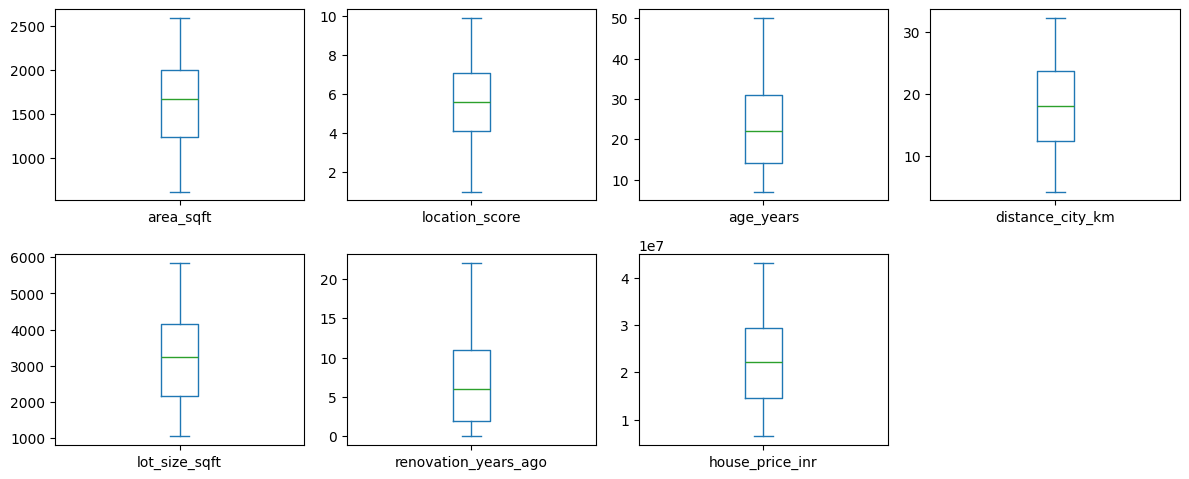

In [52]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols = num_cols.drop(['house_id','has_pool','has_garage','bathrooms','bedrooms'], errors='ignore')

df[num_cols].plot(kind='box', subplots=True, layout=(5,4), figsize=(12,12))
plt.tight_layout()
plt.title("Boxplot after outlier removal")
plt.show()

* Distribution before function tramsformation

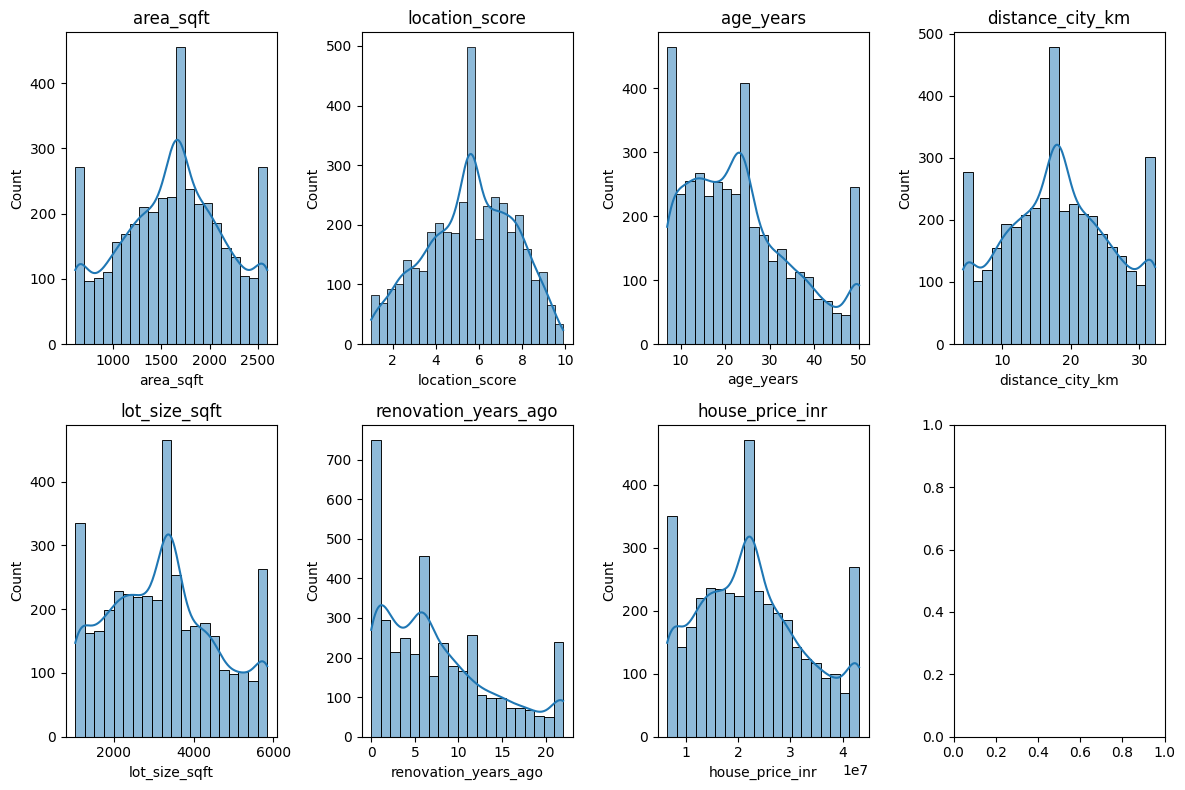

In [56]:
fig, axes = plt.subplots(2, 4, figsize=(12, 8))

axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i])
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

* Applying FunctionTransformer to remove skewness and make distribution normal

In [65]:
from sklearn.preprocessing import FunctionTransformer

log_cols = ['house_price_inr', 'lot_size_sqft', 'area_sqft']
sqrt_cols = ['distance_city_km', 'age_years']
reciprocal_cols = ['renovation_years_ago']

for col in log_cols + sqrt_cols + reciprocal_cols:
    if (df[col] <= 0).any():
        df[col] = df[col] - df[col].min() + 1

log_transformer = FunctionTransformer(np.log1p)
df[log_cols] = log_transformer.fit_transform(df[log_cols])

sqrt_transformer = FunctionTransformer(np.sqrt)
df[sqrt_cols] = sqrt_transformer.fit_transform(df[sqrt_cols])

reciprocal_transformer = FunctionTransformer(lambda x: 1 / x)
df[reciprocal_cols] = reciprocal_transformer.fit_transform(df[reciprocal_cols])

* Distribution after function tramsformation

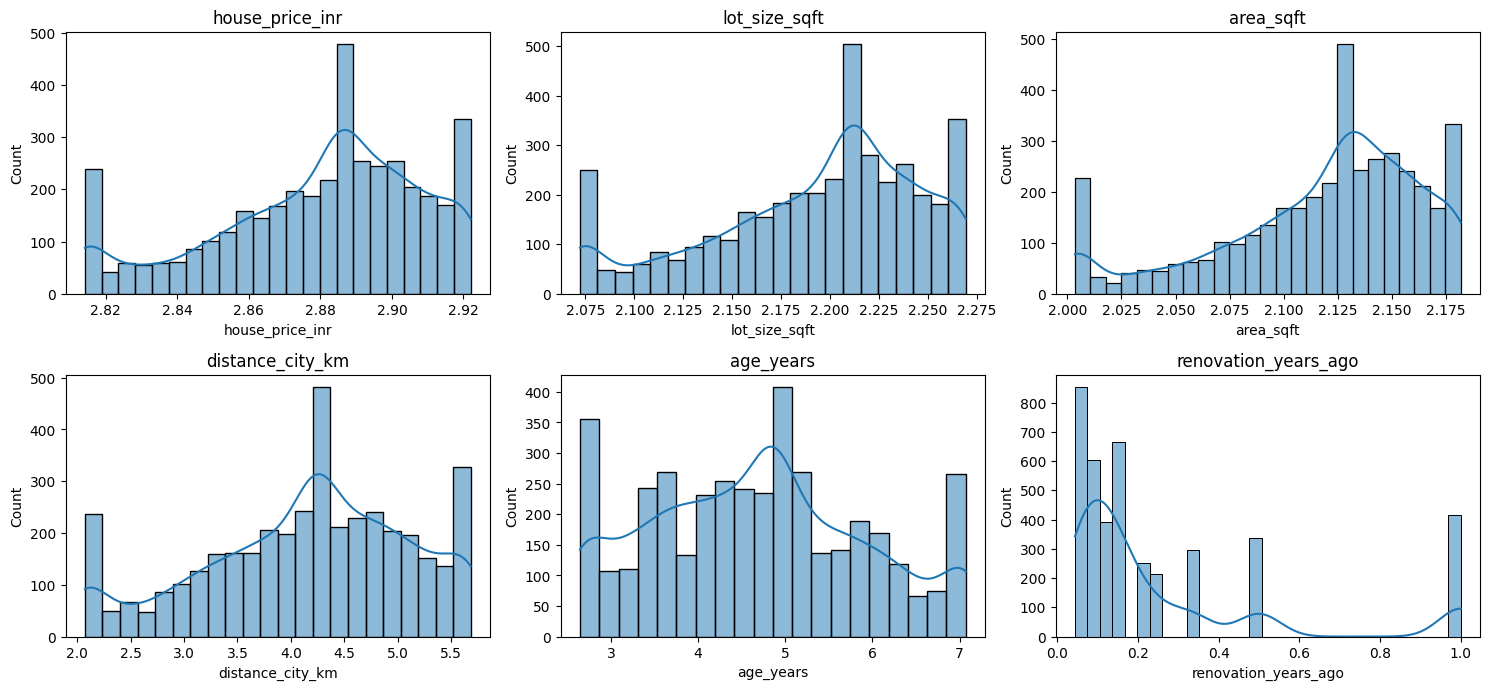

In [68]:
cols = ['house_price_inr','lot_size_sqft','area_sqft','distance_city_km','age_years','renovation_years_ago']

plt.figure(figsize=(15,10))

for i, col in enumerate(cols, 1):
    plt.subplot(3, 3, i)
    sns.histplot(df[col], kde=True)
    plt.title(col)

plt.tight_layout()
plt.show()

* After transformation

In [69]:
df

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,2.150345,5.0,4.0,7.600000,4.795832,3.449638,2.257634,1.0,0.0,1.000000,2.918378
1,100002,2.122631,3.0,3.0,6.300000,3.605551,3.974921,2.226175,1.0,0.0,0.071429,2.896153
2,100003,2.155971,4.0,3.0,5.800000,3.000000,4.593474,2.210956,0.0,0.0,0.100000,2.901072
3,100004,2.181742,5.0,3.0,5.610638,3.464102,2.810694,2.210956,1.0,1.0,0.200000,2.922039
4,100005,2.117767,3.0,3.0,3.800000,3.872983,4.898979,2.184655,0.0,0.0,0.062500,2.873026
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,104196,2.103180,4.0,2.0,4.900000,4.582576,4.427189,2.182219,1.0,0.0,0.045455,2.874889
4196,104197,2.171121,6.0,4.0,6.900000,7.071068,4.989990,2.229750,1.0,0.0,0.066667,2.918467
4197,104198,2.008277,2.0,2.0,4.500000,4.873475,4.404543,2.097525,1.0,0.0,0.142857,2.814194
4198,104199,2.003518,2.0,2.0,7.500000,5.099020,4.257549,2.072185,0.0,0.0,0.100000,2.826391


* Scaling the data

In [70]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, MaxAbsScaler, RobustScaler, Normalizer

std_cols = ['house_price_inr', 'area_sqft']
std_scaler = StandardScaler()
df[std_cols] = std_scaler.fit_transform(df[std_cols])

minmax_cols = ['distance_city_km']
minmax_scaler = MinMaxScaler()
df[minmax_cols] = minmax_scaler.fit_transform(df[minmax_cols])

norm_cols = ['age_years']
normalizer = Normalizer()
df[norm_cols] = normalizer.fit_transform(df[norm_cols])

robust_cols = ['lot_size_sqft']
robust_scaler = RobustScaler()
df[robust_cols] = robust_scaler.fit_transform(df[robust_cols])

maxabs_cols = ['renovation_years_ago']
maxabs_scaler = MaxAbsScaler()
df[maxabs_cols] = maxabs_scaler.fit_transform(df[maxabs_cols])

* After scaling

In [71]:
df

,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,0.690424,5.0,4.0,7.600000,1.0,0.381197,0.700302,1.0,0.0,1.000000,1.327625
1,100002,0.101317,3.0,3.0,6.300000,1.0,0.526719,0.268813,1.0,0.0,0.071429,0.566003
2,100003,0.810017,4.0,3.0,5.800000,1.0,0.698079,0.060065,0.0,0.0,0.100000,0.734562
3,100004,1.357822,5.0,3.0,5.610638,1.0,0.204188,0.060065,1.0,1.0,0.200000,1.453055
4,100005,-0.002070,3.0,3.0,3.800000,1.0,0.782714,-0.300670,0.0,0.0,0.062500,-0.226520
...,...,...,...,...,...,...,...,...,...,...,...,...
4195,104196,-0.312131,4.0,2.0,4.900000,1.0,0.652012,-0.334090,1.0,0.0,0.045455,-0.162661
4196,104197,1.132068,6.0,4.0,6.900000,1.0,0.807927,0.317848,1.0,0.0,0.066667,1.330651
4197,104198,-2.329455,2.0,2.0,4.500000,1.0,0.645738,-1.495740,1.0,0.0,0.142857,-2.242570
4198,104199,-2.430618,2.0,2.0,7.500000,1.0,0.605016,-1.843304,0.0,0.0,0.100000,-1.824584


* Final dataset

In [72]:
df.to_csv('real_estate_preprocessed.csv', index=False)